模型準確率: 1.0

分類報告:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         2

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



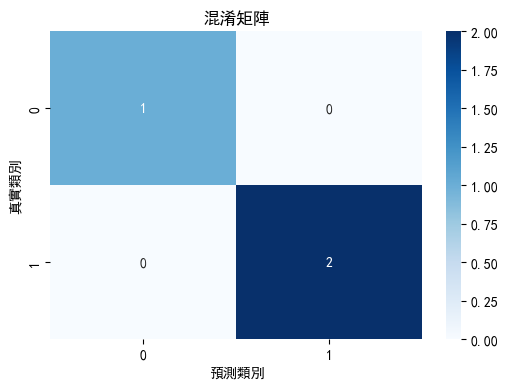

交叉驗證平均準確率：0.70 ± 0.16


In [4]:
# 實驗四：貝氏分類（Gaussian Naive Bayes）- 天氣預測打球（提升準確率）

# 步驟 1：導入必要的庫
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
import matplotlib as mpl

# 設定中文顯示
mpl.rcParams['font.family'] = 'SimHei'
mpl.rcParams['axes.unicode_minus'] = False

# 步驟 2：資料讀取與處理
df = pd.read_csv('weather_data.csv')

# 使用LabelEncoder處理非數值特徵
label_encoders = {}
for column in ['Outlook', 'Temp', 'Humidity', 'Wind', 'Tennis']:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])
    label_encoders[column] = le

# 設定訓練目標
X = df[['Outlook', 'Temp', 'Humidity', 'Wind']]
y = df['Tennis']

# 步驟 3：資料切分（提高訓練比例）與標準化
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 步驟 4：建立 Gaussian Naive Bayes 模型（嘗試使用較大數據集比例訓練）
model = GaussianNB()
model.fit(X_train_scaled, y_train)

# 預測與評估
y_pred = model.predict(X_test_scaled)
print('模型準確率:', accuracy_score(y_test, y_pred))
print("\n分類報告:\n", classification_report(y_test, y_pred))

# 步驟 5：混淆矩陣視覺化
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d')
plt.xlabel('預測類別')
plt.ylabel('真實類別')
plt.title('混淆矩陣')
plt.show()

# 步驟 6：交叉驗證提升模型穩定性
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, scaler.fit_transform(X), y, cv=5)
print(f'交叉驗證平均準確率：{np.mean(scores):.2f} ± {np.std(scores):.2f}')